# SMS Spam Detector - training pipeline

Running this notebook top to bottom trains the model from `spam.csv` and writes `spam.pkl` (classifier) and `vectorizer.pkl` (fitted CountVectorizer). `app.py` loads those two files, so nothing has to be created by hand.

In [1]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

Matplotlib is building the font cache; this may take a moment.


## 1. Load and clean the data

The CSV has three empty trailing columns, so only the first two are read.

In [2]:
data = pd.read_csv("spam.csv", encoding="latin-1", usecols=[0, 1])
data.columns = ["class", "message"]
data.head()

,class,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
data["class"] = data["class"].map({"ham": 0, "spam": 1})
print("Missing values:\n", data.isnull().sum(), sep="")
print("Exact duplicate messages:", data.duplicated().sum())

Missing values:
class      0
message    0
dtype: int64
Exact duplicate messages: 403


The dataset contains exact duplicate messages. If a duplicate landed in both the train and test sets, the model would be scored on text it already saw, so duplicates are removed **before** splitting.

In [4]:
data = data.drop_duplicates().reset_index(drop=True)
print("Messages after de-duplication:", len(data))
print(data["class"].value_counts().rename({0: "ham", 1: "spam"}))

Messages after de-duplication: 5169
class
ham     4516
spam     653
Name: count, dtype: int64


## 2. Split first, then vectorize

The split happens on the raw text. The vectorizer is fitted on the training messages only, so no vocabulary from the test set leaks into training. The split is stratified so train and test keep the same spam ratio.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["message"],
    data["class"],
    test_size=0.2,
    random_state=42,
    stratify=data["class"],
)
print("Train:", len(X_train_text), " Test:", len(X_test_text))

Train: 4135  Test: 1034


In [6]:
cv = CountVectorizer()
x_train = cv.fit_transform(X_train_text)  # fit on training data only
x_test = cv.transform(X_test_text)        # test data is only transformed
print("Vocabulary size (train only):", len(cv.vocabulary_))

Vocabulary size (train only): 7591


## 3. Train the model

In [7]:
model = MultinomialNB()
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3613., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7591)","[[ 0., 0., 1.,..., 0., 4., 1.], [ 7.,23., 0.,..., 1., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7591)","[[-10.9 ,-10.9 ,-10.2 ,...,-10.9 , -9.29,-10.2 ], [ -7.81, -6.71, -9.89,..., -9.2 , -9.89, -9.89]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7591


## 4. Evaluate

The data is imbalanced (mostly ham), so accuracy alone can look good even when spam is missed. Precision, recall and F1 are reported for the spam class (label 1).

In [8]:
y_pred = model.predict(x_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}  (of messages flagged spam, how many were)")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}  (of real spam, how much was caught)")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=4))

Accuracy : 0.9865
Precision: 0.9756  (of messages flagged spam, how many were)
Recall   : 0.9160  (of real spam, how much was caught)
F1-score : 0.9449

              precision    recall  f1-score   support

         ham     0.9879    0.9967    0.9923       903
        spam     0.9756    0.9160    0.9449       131

    accuracy                         0.9865      1034
   macro avg     0.9818    0.9564    0.9686      1034
weighted avg     0.9864    0.9865    0.9863      1034



[[900   3]
 [ 11 120]]
True ham: 900 | False spam (ham blocked): 3 | Missed spam: 11 | Caught spam: 120


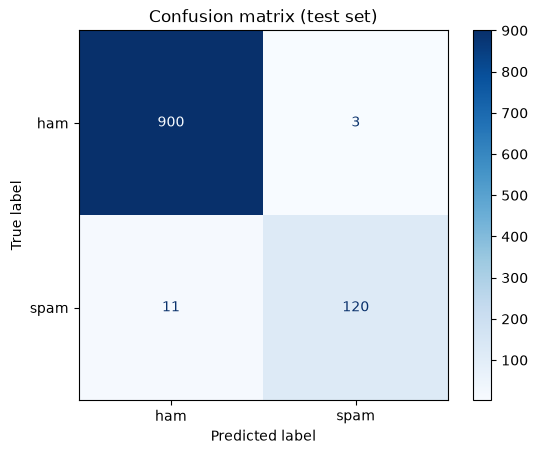

In [9]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(cm)
print(f"True ham: {tn} | False spam (ham blocked): {fp} | Missed spam: {fn} | Caught spam: {tp}")

ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

## 5. Save the model and the fitted vectorizer

Both files are needed by `app.py`. The vectorizer must be the exact one the model was trained with, because the model's features are positions in its vocabulary.

In [10]:
with open("spam.pkl", "wb") as f:
    pickle.dump(model, f)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(cv, f)
print("Saved spam.pkl and vectorizer.pkl")

Saved spam.pkl and vectorizer.pkl


## 6. Verify the saved files

Reload both pickles from disk and check they reproduce the in-memory predictions exactly, which is what the app does at startup.

In [11]:
with open("spam.pkl", "rb") as f:
    saved_model = pickle.load(f)
with open("vectorizer.pkl", "rb") as f:
    saved_cv = pickle.load(f)

assert saved_cv.vocabulary_ == cv.vocabulary_, "Saved vectorizer differs from the trained one"
assert (saved_model.predict(saved_cv.transform(X_test_text)) == y_pred).all(), \
    "Reloaded model gives different predictions"
print("Reloaded model and vectorizer reproduce the test predictions exactly.")

def classify(msg):
    return "spam" if saved_model.predict(saved_cv.transform([msg]))[0] == 1 else "not spam"

for msg in [
    "Congratulations! You won a free prize. Text WIN to 80085 now to claim your 500 cash",
    "Are we still meeting for lunch tomorrow?",
]:
    print(f"{classify(msg):>8} <- {msg}")

Reloaded model and vectorizer reproduce the test predictions exactly.
    spam <- Congratulations! You won a free prize. Text WIN to 80085 now to claim your 500 cash
not spam <- Are we still meeting for lunch tomorrow?
